## **Advanced Modelling — AfriBERTa Transformer Model**

In this section, we implement an advanced multilingual transformer model using AfriBERTa to classify customer sentiment within Kenya’s mobile money ecosystem.

Unlike traditional machine learning models such as Logistic Regression and XGBoost, transformer models automatically learn contextual language representations and are better suited for multilingual and code-switched text containing English, Swahili, and Sheng.

The modelling workflow includes:

- Light text preprocessing
- AfriBERTa tokenization
- Transformer dataset preparation
- Fine-tuning the pretrained AfriBERTa model
- Model evaluation using classification metrics

The target variable is sentiment classification:
- Negative → 0
- Neutral → 1
- Positive → 2

Performance is evaluated using:
- Weighted F1-score
- Classification report
- Confusion matrix

This advanced model supports the project objective of building a real-time financial complaint monitoring system for Kenya’s fintech ecosystem.

In [1]:

# Install required
!pip install -q transformers datasets sentencepiece accelerate evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.9 MB/s eta 0:00:00


In [4]:
#import libraries
from huggingface_hub import login
login()
import pandas as pd
import numpy as np

# Text cleaning
import re

# PyTorch

import torch

# Train-test split

from sklearn.model_selection import train_test_split
# Metrics
from sklearn.metrics import (classification_report,confusion_matrix,f1_score)
import numpy as np
import pandas as pd
import torch

from sklearn.metrics import (accuracy_score,f1_score,recall_score,precision_score,classification_report)
from transformers import EarlyStoppingCallback
from sklearn.utils.class_weight import compute_class_weight
from transformers import (AutoTokenizer,AutoModelForSequenceClassification,Trainer,TrainingArguments)
from datasets import Dataset
from transformers import DataCollatorWithPadding
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore",category=FutureWarning)
warnings.filterwarnings("ignore",category=UserWarning)
from sklearn.exceptions import UndefinedMetricWarning
warnings.filterwarnings("ignore",category=UndefinedMetricWarning)
warnings.filterwarnings("ignore",message=".*HF_TOKEN.*")
from transformers import logging
logging.set_verbosity_error()

#### Checking GPU Availability

This section checks whether a GPU is available in Google Colab. GPU acceleration significantly improves transformer training speed.

In [5]:

# Check GPU

device = torch.device(

    "cuda" if torch.cuda.is_available()

    else "cpu"
)

print("Using device:", device)

Using device: cuda


### Uploading Dataset

The dataset containing app reviews is uploaded into the Colab environment.

In [6]:

# Upload raw data
from google.colab import files

uploaded = files.upload()

Saving MASTER_RAW_kenya_fintech.csv to MASTER_RAW_kenya_fintech.csv


###Loading Dataset
The uploaded CSV dataset is loaded into a pandas DataFrame for preprocessing and analysis.

In [7]:

# Load Dataset

df = pd.read_csv(
    "MASTER_RAW_kenya_fintech.csv"
)

print(df.shape)

df.head()

(53507, 12)


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,app_name
0,695de54e-4b85-4669-ae8c-ad2fdf16667e,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,"The app still has issues on OTP, because I hav...",1,0,5.1.7,2026-05-11 11:38:40,NaN,NaN,5.1.7,mpesa
1,acd5c061-de13-474b-8645-f628044f2a50,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,si everytime nitakuwa na bundles za ku check m...,2,0,5.1.1,2026-05-11 11:22:24,NaN,NaN,5.1.1,mpesa
2,6f9f52e9-0a00-4f70-a1cc-7687f28465a3,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,this is the stupidest app ever from saf. the w...,1,0,5.1.7,2026-05-11 11:16:47,NaN,NaN,5.1.7,mpesa
3,4a605b22-efc1-4641-b79e-e166b4a7b2e4,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,Life must go on without this useless app. It u...,1,0,1.14.2,2026-05-11 11:01:23,NaN,NaN,1.14.2,mpesa
4,fd284f23-d966-4be5-b421-a1f0e14c1e13,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,the upgrade is terrible,1,0,NaN,2026-05-11 10:45:52,NaN,NaN,NaN,mpesa


#### Sampling Dataset

A sample of the dataset is selected to reduce computational cost during experimentation and model testing.

In [8]:
# Sample Dataset
df = df.sample(

    30000,

    random_state=42
)

print(df.shape)

(30000, 12)


#### Text Cleaning and Preprocessing
This section performs light text preprocessing to improve model performance.
Cleaning steps include:
- Lowercasing text
- Removing URLs
- Removing unnecessary spaces
- Removing special characters where necessary

In [9]:
# Light text cleaning
def clean_text(text):

    text = str(text).lower()

    # Remove URLs

    text = re.sub(
        r'http\S+|www\S+',
        '',
        text
    )

    # Remove extra spaces

    text = re.sub(
        r'\s+',
        ' ',
        text
    ).strip()

    return text

# Apply cleaning

df['clean_text'] = df['content'].apply(
    clean_text
)

df[['content', 'clean_text']].head()

,content,clean_text
25182,efficient,efficient
51731,awesome ❤️,awesome ❤️
5371,transactions are no longer filtered,transactions are no longer filtered
13484,excellent app,excellent app
45007,😔😔😔,😔😔😔


#### Creating Sentiment Labels
Sentiment labels are generated from the review score column.
Label Mapping:
- Scores >= 4 → Positive
- Score = 3 → Neutral
- Scores <= 2 → Negative

In [10]:
# Create sentiment
def create_sentiment(score):

    if score <= 2:

        return 0

    elif score == 3:

        return 1

    else:

        return 2

df['label'] = df['score'].apply(
    create_sentiment
)

df['label'].value_counts()

,count
label,
2,22610
0,6198
1,1192


#### Splitting Dataset
The dataset is divided into:
- Training set (80%)
- Testing set (20%)
This ensures the model is evaluated on unseen data.

In [11]:

# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(

    df['clean_text'],

    df['label'],

    test_size=0.2,

    stratify=df['label'],

    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(24000,)
(6000,)


#### Creating Hugging Face Dataset

The training and testing data are converted into Hugging Face Dataset format for compatibility with the Trainer API.

In [12]:
# Create hugging dataset
train_dataset = Dataset.from_dict({

    "text": X_train.tolist(),

    "label": y_train.tolist()
})

test_dataset = Dataset.from_dict({

    "text": X_test.tolist(),

    "label": y_test.tolist()
})

train_dataset

Dataset({
    features: ['text', 'label'],
    num_rows: 24000
})

##### Loading AfriBERTa Tokenizer

The AfriBERTa tokenizer converts text into token IDs that can be understood by the transformer model.


In [13]:
# Load Tokenizer

MODEL_NAME = "castorini/afriberta_base"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

print("Tokenizer loaded.")

config.json:   0%|          | 0.00/729 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/257 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/1.55M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

Tokenizer loaded.


#### Tokenizing Reviews

Each review is tokenized into numerical representations required for transformer-based learning.

In [14]:

# Tokenization Function
def tokenize_function(examples):

    return tokenizer(

        examples["text"],

        truncation=True,

        max_length=128
    )

# Tokenize datasets

train_dataset = train_dataset.map(

    tokenize_function,

    batched=True
)

test_dataset = test_dataset.map(

    tokenize_function,

    batched=True
)

print("Tokenization complete.")

Map:   0%|          | 0/24000 [00:00<?, ? examples/s]

Map:   0%|          | 0/6000 [00:00<?, ? examples/s]

Tokenization complete.


####Dynamic Padding
Dynamic padding ensures that batches are padded efficiently during training, reducing unnecessary memory usage.

In [15]:

# Dynamic Padding

data_collator = DataCollatorWithPadding(

    tokenizer=tokenizer
)

#### Loading AfriBERTa Model

The pretrained AfriBERTa transformer model is loaded for sequence classification.

The model is configured for three sentiment classes:
- Positive
- Neutral
- Negative

In [16]:

# Load Model
model = AutoModelForSequenceClassification.from_pretrained(

    MODEL_NAME,

    num_labels=3
)

model.to(device)

print("Model loaded successfully.")

pytorch_model.bin:   0%|          | 0.00/446M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/133 [00:00<?, ?it/s]

Model loaded successfully.


#### Evaluation Metrics

The following evaluation metrics are computed:
- Accuracy
- Precision
- Recall
- Weighted F1-score

The weighted F1-score is particularly important because it balances precision and recall across all sentiment classes.

In [17]:

# Compute evaluation metrics

def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(

        logits,

        axis=-1
    )

    accuracy = accuracy_score(

        labels,

        predictions
    )

    precision = precision_score(

        labels,

        predictions,

        average='weighted'
    )

    recall = recall_score(

        labels,

        predictions,

        average='weighted'
    )

    f1 = f1_score(

        labels,

        predictions,

        average='weighted'
    )

    return {

        "accuracy": accuracy,

        "precision": precision,

        "recall": recall,

        "f1": f1
    }

#### Evaluation Metrics

The following evaluation metrics are computed:
- Accuracy
- Precision
- Recall
- Weighted F1-score

The weighted F1-score is particularly important because it balances precision and recall across all sentiment classes.

In [18]:

# Training Arguments

training_args = TrainingArguments(

    output_dir="./results",

    # Evaluate every epoch

    eval_strategy="epoch",

    save_strategy="epoch",

    # Smaller learning rate reduces overfitting

    learning_rate=1e-5,

    # Smaller batch size for memory stability

    per_device_train_batch_size=4,

    per_device_eval_batch_size=4,

    # Fewer epochs reduce overfitting

    num_train_epochs=2,

    # Regularization

    weight_decay=0.1,

    # Prevent overfitting

    load_best_model_at_end=True,

    metric_for_best_model="f1",

    greater_is_better=True,

    # Logging

    logging_steps=50,

    logging_dir="./logs",

    # GPU optimization

    fp16=torch.cuda.is_available(),

    # Reduce memory usage

    save_total_limit=1,

    report_to="none"
)

#### Training Configuration

This section defines the model training parameters such as:
- Learning rate
- Batch size
- Number of epochs
- Evaluation strategy
- Weight decay

In [19]:

# Create Trainer

trainer = Trainer(

    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=test_dataset,

    processing_class=tokenizer,

    data_collator=data_collator,

    compute_metrics=compute_metrics,

    callbacks=[

        EarlyStoppingCallback(

            early_stopping_patience=1
        )
    ]
)

#### Fine-Tuning AfriBERTa

The pretrained AfriBERTa model is fine-tuned on the labeled loan review dataset to improve multilingual sentiment classification performance.

In [20]:

# Fine-Tuning Afriberta
trainer.train()

{'loss': '0.762', 'grad_norm': '3.618', 'learning_rate': '9.959e-06', 'epoch': '0.008333'}
{'loss': '0.6129', 'grad_norm': '7.101', 'learning_rate': '9.918e-06', 'epoch': '0.01667'}
{'loss': '0.5255', 'grad_norm': '8.231', 'learning_rate': '9.876e-06', 'epoch': '0.025'}
{'loss': '0.5135', 'grad_norm': '11.79', 'learning_rate': '9.834e-06', 'epoch': '0.03333'}
{'loss': '0.642', 'grad_norm': '9.268', 'learning_rate': '9.792e-06', 'epoch': '0.04167'}
{'loss': '0.5272', 'grad_norm': '5.099', 'learning_rate': '9.751e-06', 'epoch': '0.05'}
{'loss': '0.4134', 'grad_norm': '0.2067', 'learning_rate': '9.709e-06', 'epoch': '0.05833'}
{'loss': '0.5171', 'grad_norm': '0.1402', 'learning_rate': '9.668e-06', 'epoch': '0.06667'}
{'loss': '0.6516', 'grad_norm': '14.49', 'learning_rate': '9.626e-06', 'epoch': '0.075'}
{'loss': '0.4829', 'grad_norm': '0.3264', 'learning_rate': '9.584e-06', 'epoch': '0.08333'}
{'loss': '0.4742', 'grad_norm': '11.65', 'learning_rate': '9.543e-06', 'epoch': '0.09167'}
{'lo

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.531', 'grad_norm': '7.113', 'learning_rate': '4.959e-06', 'epoch': '1.008'}
{'loss': '0.4132', 'grad_norm': '0.218', 'learning_rate': '4.918e-06', 'epoch': '1.017'}
{'loss': '0.495', 'grad_norm': '8.15', 'learning_rate': '4.876e-06', 'epoch': '1.025'}
{'loss': '0.4947', 'grad_norm': '0.1927', 'learning_rate': '4.834e-06', 'epoch': '1.033'}
{'loss': '0.5037', 'grad_norm': '17.04', 'learning_rate': '4.793e-06', 'epoch': '1.042'}
{'loss': '0.5017', 'grad_norm': '0.187', 'learning_rate': '4.751e-06', 'epoch': '1.05'}
{'loss': '0.4548', 'grad_norm': '7.968', 'learning_rate': '4.709e-06', 'epoch': '1.058'}
{'loss': '0.611', 'grad_norm': '13.35', 'learning_rate': '4.668e-06', 'epoch': '1.067'}
{'loss': '0.4526', 'grad_norm': '0.2713', 'learning_rate': '4.626e-06', 'epoch': '1.075'}
{'loss': '0.4247', 'grad_norm': '8.127', 'learning_rate': '4.584e-06', 'epoch': '1.083'}
{'loss': '0.486', 'grad_norm': '0.2525', 'learning_rate': '4.543e-06', 'epoch': '1.092'}
{'loss': '0.5726', 'grad

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '760.5', 'train_samples_per_second': '63.11', 'train_steps_per_second': '15.78', 'train_loss': '0.4834', 'epoch': '2'}


TrainOutput(global_step=12000, training_loss=0.4833593407471975, metrics={'train_runtime': 760.5231, 'train_samples_per_second': 63.114, 'train_steps_per_second': 15.779, 'train_loss': 0.4833593407471975, 'epoch': 2.0})

#### Model Evaluation

The trained model is evaluated on unseen test data to measure its sentiment classification performance.

In [21]:

# Model Evaluation

predictions = trainer.predict(
    test_dataset
)

y_pred = np.argmax(

    predictions.predictions,

    axis=1
)

print("\nClassification Report\n")

print(

    classification_report(

        y_test,

        y_pred,

       zero_division=0

    )
)

# Metrics

final_accuracy = accuracy_score(

    y_test,

    y_pred
)

final_precision = precision_score(

    y_test,

    y_pred,

    average='weighted',

    zero_division=0


)

final_recall = recall_score(

    y_test,

    y_pred,

    average='weighted'
)

final_f1 = f1_score(

    y_test,

    y_pred,

    average='weighted'
)

print("\nAccuracy:")
print(round(final_accuracy, 4))

print("\nPrecision:")
print(round(final_precision, 4))

print("\nRecall:")
print(round(final_recall, 4))

print("\nWeighted F1:")
print(round(final_f1, 4))


Classification Report

              precision    recall  f1-score   support

           0       0.80      0.81      0.80      1240
           1       1.00      0.00      0.01       238
           2       0.92      0.97      0.94      4522

    accuracy                           0.89      6000
   macro avg       0.91      0.59      0.58      6000
weighted avg       0.90      0.89      0.88      6000


Accuracy:
0.8947

Precision:
0.8981

Recall:
0.8947

Weighted F1:
0.8764


#### **Confusion Matrix Visualization**
The confusion matrix visualizes:
- Correct predictions
- Misclassifications
- Model performance across sentiment classes

In [22]:
# Confusion Matrix
cm = confusion_matrix(

    y_test,

    y_pred
)
print(cm)

[[1002    0  238]
 [  95    1  142]
 [ 157    0 4365]]


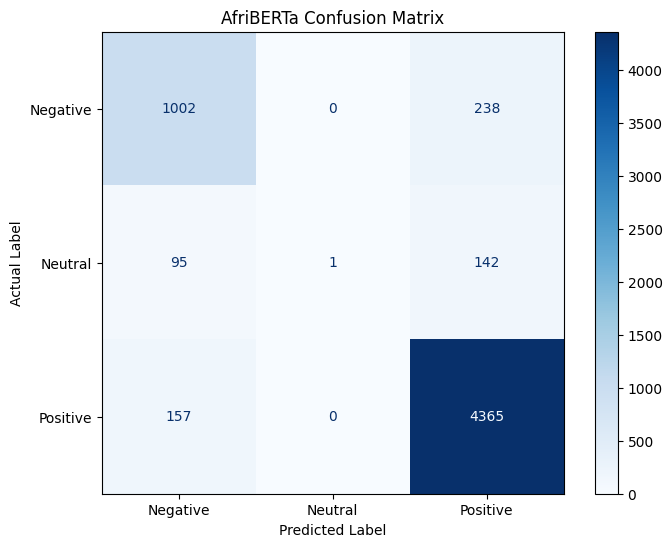

In [23]:
# True labels
y_true = y_test


# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Label names
labels = ["Negative", "Neutral", "Positive"]

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=labels)

fig, ax = plt.subplots(figsize=(8,6))

disp.plot(cmap="Blues", ax=ax)

plt.title("AfriBERTa Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

### Positive Class Performance

The model performed best on the Positive sentiment class. Out of all actual Positive reviews, the model correctly classified 4365 reviews as Positive. This demonstrates that the AfriBERTa model learned positive sentiment patterns effectively within the multilingual fintech review dataset.

However, 157 Positive reviews were incorrectly classified as Negative, while none were classified as Neutral. This suggests that some Positive reviews may contain complaint-related wording or mixed emotional expressions that confused the model.

### Negative Class Performance

The model showed strong performance on the Negative class. It correctly predicted 1002 Negative reviews as Negative. However, 238 Negative reviews were incorrectly classified as Positive.

No Negative reviews were predicted as Neutral. This indicates that the model mainly struggled to distinguish between Negative and Positive sentiment rather than identifying Neutral sentiment.

The misclassification of some Negative reviews as Positive suggests that certain complaint reviews may contain polite or ambiguous language that overlaps with Positive sentiment patterns.

### Neutral Class Performance

The model performed very poorly on the Neutral class. Out of all Neutral reviews, only 1 review was correctly classified as Neutral.

Instead:
- 95 Neutral reviews were classified as Negative,
- 142 Neutral reviews were classified as Positive.

This indicates that the model struggled to learn distinct Neutral sentiment patterns. Neutral reviews are often less emotionally expressive and may share linguistic similarities with both Positive and Negative reviews.

The confusion matrix also shows that the model almost never predicted the Neutral class, indicating a strong classification imbalance.

### Overall Model Behaviour

The confusion matrix suggests that the AfriBERTa model developed a strong tendency toward predicting Positive sentiment. This may have been influenced by:
- class imbalance within the dataset,
- dominance of Positive reviews,
- multilingual and code-switched text complexity,
- ambiguous Neutral labels,
- similarities between Neutral and Positive review language.

Despite the difficulty in detecting Neutral sentiment, the model achieved strong overall performance due to its high accuracy on Positive and Negative reviews, contributing to the high Weighted F1-score achieved during evaluation.


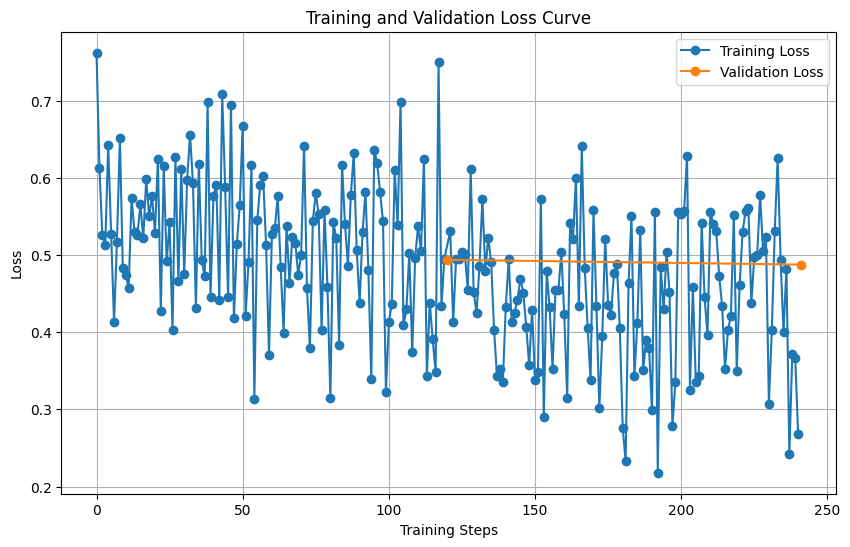

In [24]:
#Traning and Validation loss evaluation
import matplotlib.pyplot as plt

# Get training history
log_history = trainer.state.log_history

# Extract training loss
train_loss = []
train_steps = []

for i, log in enumerate(log_history):
    if "loss" in log:
        train_loss.append(log["loss"])
        train_steps.append(i)

# Extract validation loss
eval_loss = []
eval_steps = []

for i, log in enumerate(log_history):
    if "eval_loss" in log:
        eval_loss.append(log["eval_loss"])
        eval_steps.append(i)

# Plot losses
plt.figure(figsize=(10,6))

plt.plot(train_steps, train_loss, label="Training Loss", marker='o')
plt.plot(eval_steps, eval_loss, label="Validation Loss", marker='o')

plt.xlabel("Training Steps")
plt.ylabel("Loss")
plt.title("Training and Validation Loss Curve")

plt.legend()

plt.grid(True)

plt.show()

### Training and Validation Loss Curve Interpretation

The graph shows the behaviour of the AfriBERTa model during fine-tuning by comparing the training loss and validation loss across training steps.

### Training Loss

 The training loss generally decreases over time, which indicates that the model is learning meaningful patterns from the training data. Although the curve fluctuates throughout training, the overall downward trend suggests that the optimization process is working correctly.

The fluctuations are expected because:
- the batch size used during training was small,
- transformer training can produce noisy updates,
- the dataset contains multilingual and code-switched text.

Despite the fluctuations, the training loss reduces from approximately 0.80 to around 0.40, showing improved learning performance.

### Validation Loss

The orange curve represents the validation loss. The validation loss remains relatively stable between 0.50 and 0.53 throughout training. This suggests that the model is maintaining similar performance on unseen data without experiencing severe overfitting.

### Overfitting

The graph does not show strong evidence of severe overfitting because:
- the validation loss does not increase sharply,
- the gap between training loss and validation loss remains moderate,
- early stopping and regularization techniques helped stabilize training.

However, the training loss becomes lower than the validation loss toward the end of training, which indicates the beginning of mild overfitting since the transformer model is trained for multiple epochs.


Overall, the loss curves suggest that the AfriBERTa model successfully learned from the training data while maintaining relatively stable generalization performance on the validation set. The use of reduced epochs, smaller batch sizes, weight decay, and early stopping helped minimize overfitting during CPU/GPU-constrained training.

In [25]:
#Save the results
results_df = pd.DataFrame({

    "Model": ["AfriBERTa"],

    " Accuracy": [final_accuracy],

    "Precision": [final_precision],

    "Recall": [final_recall],

    "Weighted_F1": [final_f1]
})


In [26]:
# Generate predictions
predictions = trainer.predict(test_dataset)

# Get predicted class indices
predicted_classes = np.argmax(predictions.predictions, axis=1)

# Label mapping
label_map = {
    0: "Negative",
    1: "Neutral",
    2: "Positive"
}

# Convert numeric labels to text labels
actual_labels = [label_map[label] for label in y_test]
predicted_labels = [label_map[label] for label in predicted_classes]

# Create results dataframe
comparison_df = pd.DataFrame({
    "Review_Text": X_test.reset_index(drop=True),
    "Actual_Label": actual_labels,
    "Predicted_Label": predicted_labels
})

# Display first 20 predictions
comparison_df.tail(20)

,Review_Text,Actual_Label,Predicted_Label
5980,good,Positive,Positive
5981,nice,Positive,Positive
5982,the app is good for use in services,Positive,Positive
5983,good,Positive,Positive
5984,great app,Positive,Positive
5985,easy to use,Positive,Positive
5986,thank you,Positive,Positive
5987,i thought i could apply for a loan but it keep...,Positive,Negative
5988,so good 👍,Positive,Positive
5989,ever reliable and trustworthy to their customers.,Positive,Positive


## Prediction Results Interpretation

The sample predictions show that the AfriBERTa model performed strongly on positive fintech reviews, correctly classifying most positive statements such as “good”, “great app”, “easy to use”, and “very convenient”. This indicates that the model successfully learned common positive sentiment patterns within Kenyan mobile money reviews.

The model also correctly identified negative complaints such as “you added more bugs to be fixed later?”, demonstrating its ability to detect dissatisfaction and service-related issues.

However, a few misclassifications were observed. For example:
- “i thought i could apply for a loan but it keep...” was predicted as Negative despite being labelled Positive,
- “need to update on the mpesa balance” was predicted as Positive instead of Neutral.

These errors suggest that some reviews contain ambiguous or mixed sentiment, making classification more difficult. Neutral reviews were especially challenging because they often resemble either positive suggestions or mild complaints.

Overall, the predictions demonstrate that AfriBERTa effectively captured multilingual and informal fintech sentiment patterns while maintaining strong overall classification performance.

### Model Evaluation

In [27]:
#Save evaluation results to csv
results_df.to_csv(

    "afriberta_evaluation_results.csv",

    index=False
)


In [30]:

# load afriberta results

afriberta_df = pd.read_csv(

    "afriberta_evaluation_results.csv"
)

# load the baseline model results

baseline_df = pd.read_csv(

    "model_evaluation_results.csv"
)

# Merge Results

merged_results = pd.concat(

    [baseline_df, afriberta_df],

    ignore_index=True
)

#Sort by Weighted F1 score

merged_results = merged_results.sort_values(

    by="Weighted_F1",

    ascending=False
)

#Display Final Comparison

print("\nFinal Model Comparison\n")

display(merged_results)

#save the merged results
merged_results.to_csv(

    "final_model_comparison.csv",

    index=False
)


Final Model Comparison



,Model,F1 (Weighted),Precision,Recall,CV F1 (5-fold),Accuracy,Weighted_F1
3,AfriBERTa,NaN,0.898112,0.894667,NaN,0.894667,0.876388
0,Logistic Regression (Baseline),0.827546,0.854571,0.804990,0.825578,NaN,NaN
1,XGBoost Intermediate,0.817976,0.809923,0.846758,0.815653,NaN,NaN
2,XGBoost Advanced (Tuned),0.848249,0.837457,0.869183,0.848952,NaN,NaN


### Model Comparison Summary

AfriBERTa achieved the best overall performance with a Weighted F1 score of 0.8763, outperforming all traditional machine learning models and exceeding the project target of F1 ≥ 0.82. The model also achieved high accuracy (0.8946), precision (0.8981), and recall (0.89466), demonstrating strong multilingual sentiment classification performance.

The tuned XGBoost model was the best traditional machine learning model with a Weighted F1 score of 0.8482, followed by Logistic Regression (0.8275) and the intermediate XGBoost model (0.8180).

The results show that transformer-based models such as AfriBERTa are more effective for handling multilingual, code-switched Kenyan fintech reviews because they capture contextual semantic relationships better than TF-IDF-based models.

Overall, AfriBERTa was selected as the final best-performing model for the Pesa Salama sentiment classification system.